In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import warnings
warnings.filterwarnings("ignore")  
from sklearn.preprocessing import StandardScaler
# from scipy.stats import pearsonr

In [5]:
df = pd.read_csv("insurance.csv", encoding_errors="ignore")

In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [8]:
df.describe().all()

age          True
bmi          True
children    False
charges      True
dtype: bool

In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [12]:
df.shape

(1338, 7)

In [13]:
df.ndim

2

In [14]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(1)

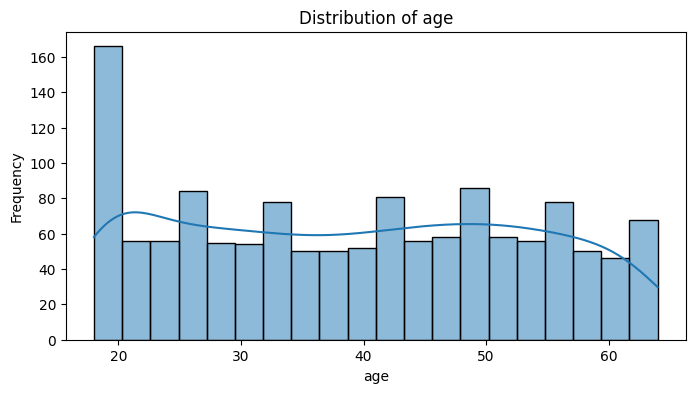

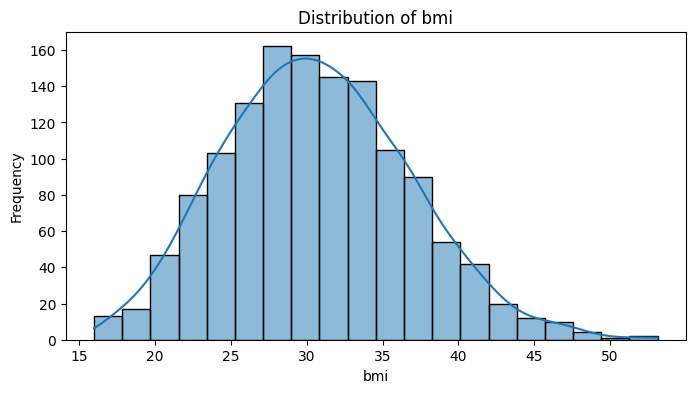

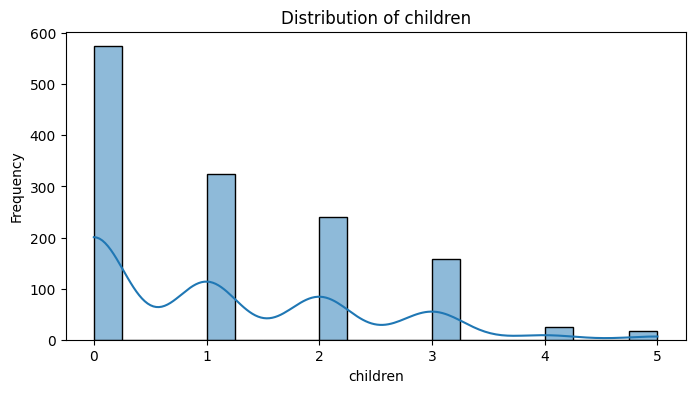

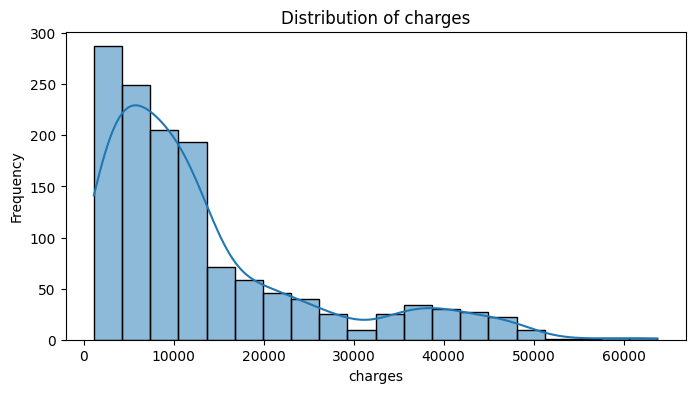

In [18]:
cols_numeric = ["age", "bmi", "children", "charges"]
for col in cols_numeric:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Axes: xlabel='children', ylabel='count'>

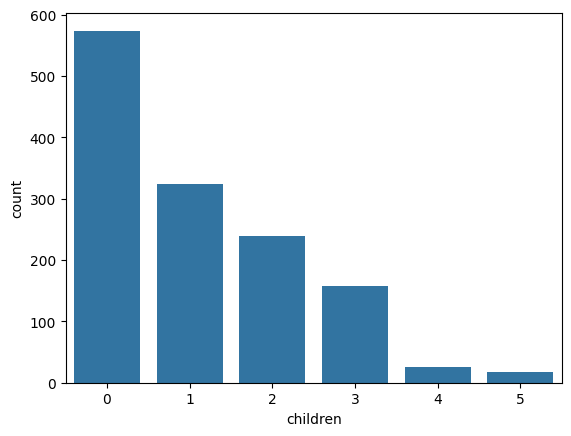

In [19]:
sns.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

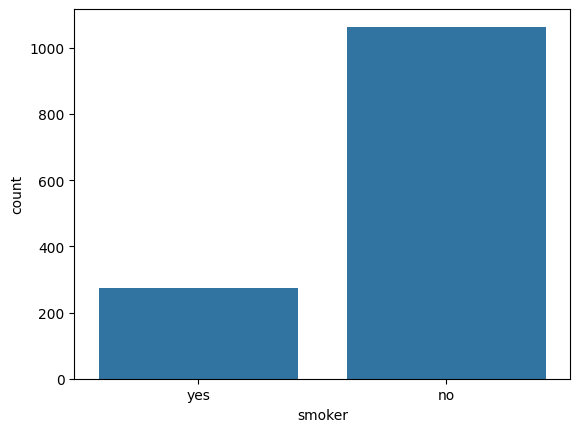

In [20]:
sns.countplot(x = df['smoker'])

<Axes: xlabel='sex', ylabel='count'>

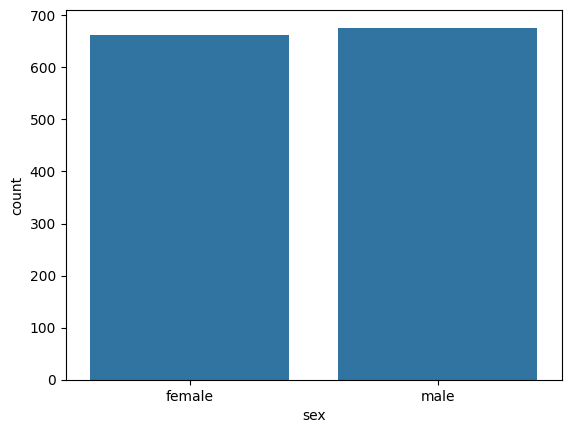

In [21]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='charges'>

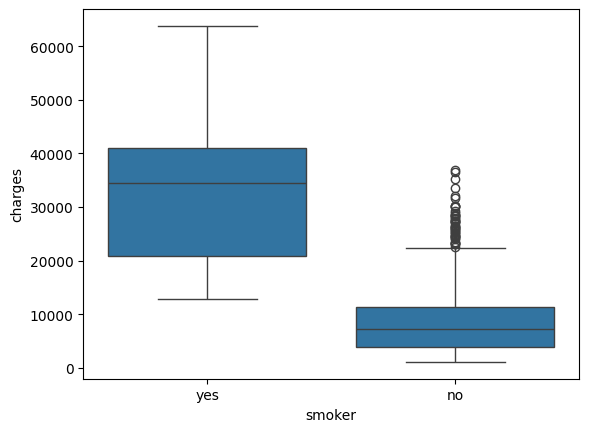

In [22]:
sns.boxplot(x=df['smoker'], y=df['charges'])

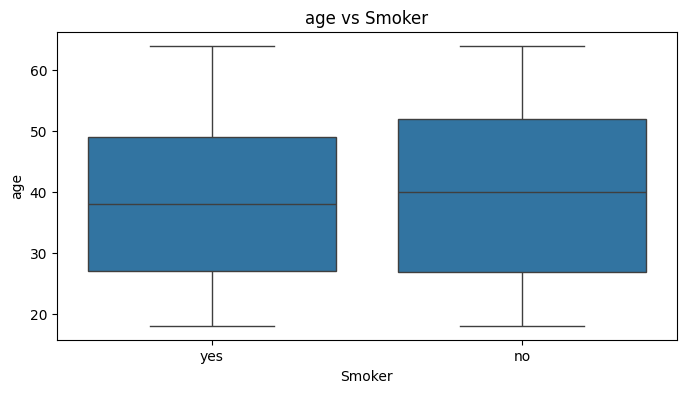

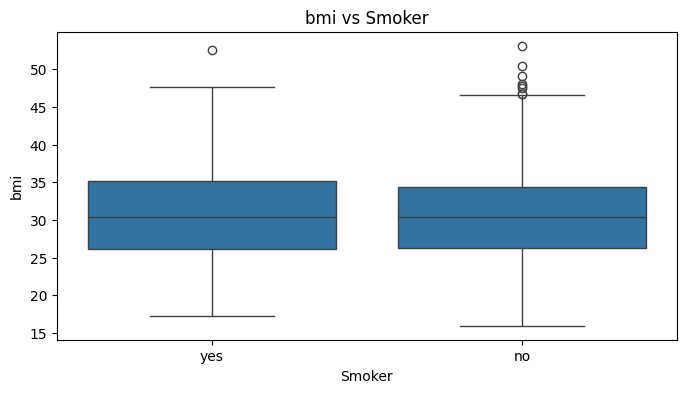

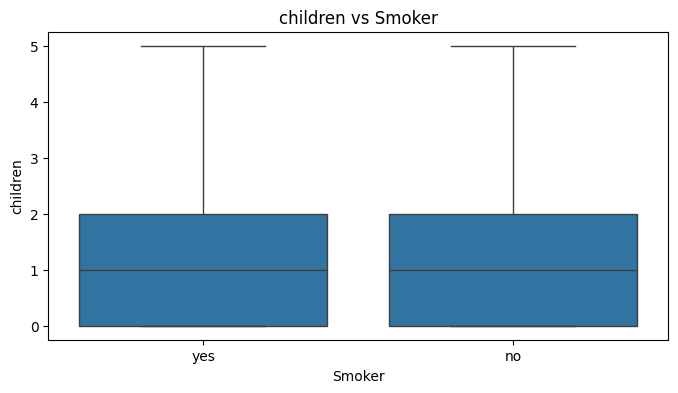

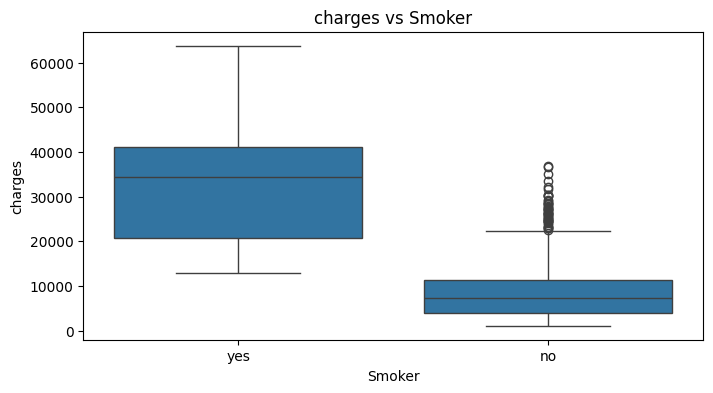

In [23]:
for col in cols_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df['smoker'], y=df[col])
    plt.title(f"{col} vs Smoker")
    plt.xlabel("Smoker")
    plt.ylabel(col)
    plt.show()

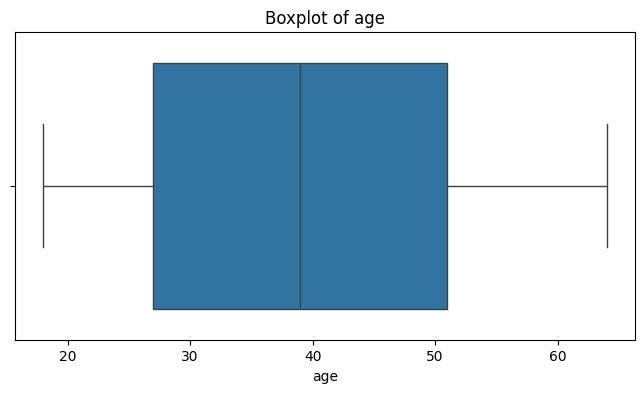

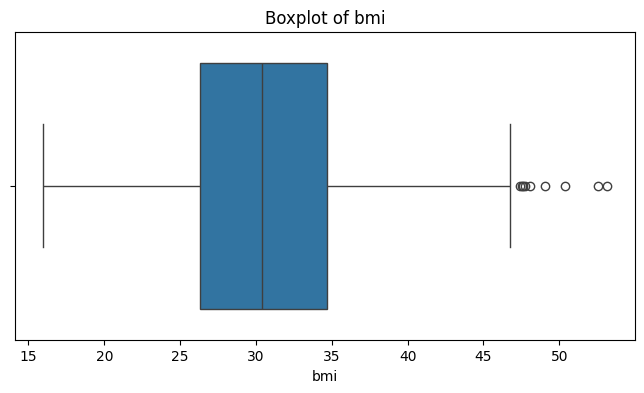

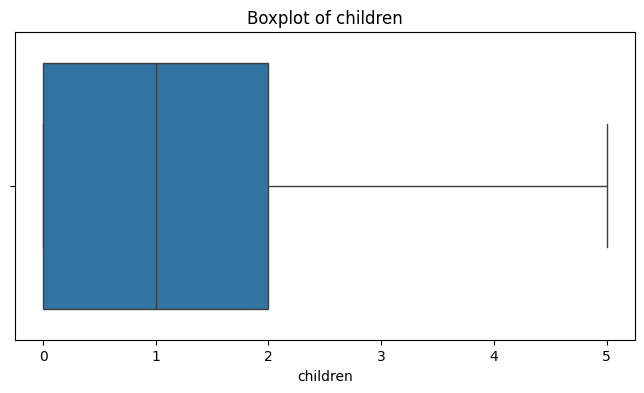

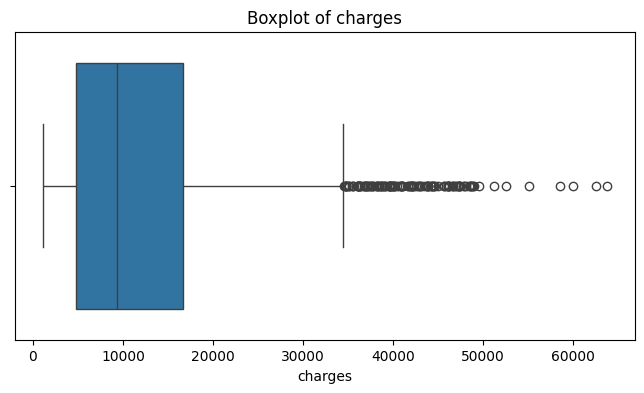

In [25]:
for col in cols_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x =df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

<Axes: >

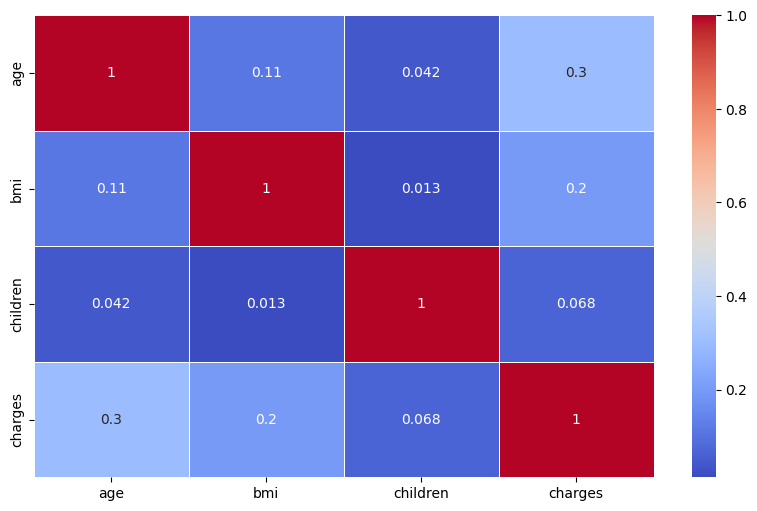

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)

DATA CLEANING


In [27]:
df_clean = df.copy()

In [35]:
# This returns the cleaned DataFrame and assigns it perfectly
df_clean = df.drop_duplicates()

In [ ]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df.shape

(1337, 7)

In [41]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [42]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [43]:
sex_mapping = {
    'male' : 0,
    'female' : 1
}

df['sex'] = df['sex'].map(sex_mapping)
df['sex'].value_counts()

sex
0    675
1    662
Name: count, dtype: int64

In [44]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [ ]:
smoker_mapping = {
    'no' : 0,
    'yes' : 1
}

df['smoker'] = df['smoker'].map(smoker_mapping)
df['smoker'].value_counts()

smoker
0    1063
1     274
Name: count, dtype: int64

In [47]:
df.rename(columns = {
    'smoker' : 'is_smoker',
    'sex' : 'is_female'
}, inplace=True)

In [48]:
df.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [49]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [50]:
df = pd.get_dummies(df, columns =['region'], drop_first=True)

In [51]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [53]:
df = df.astype(int)
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

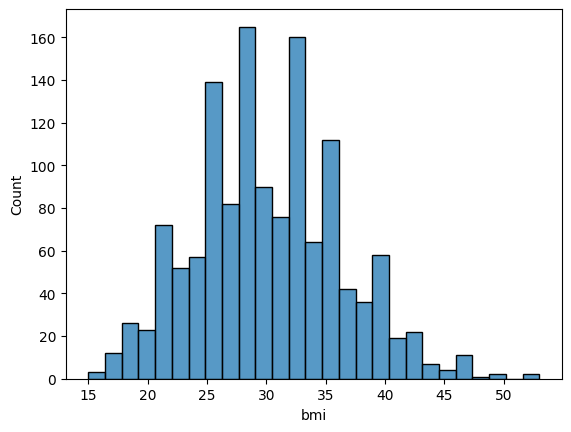

In [55]:
sns.histplot(df['bmi'])

In [56]:
df['bmi_category'] = pd.cut(df['bmi'], bins = [0,18.5,25,30,100], labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese'])
df[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,27,Overweight
1,33,Obese
2,33,Obese
3,22,Normal weight
4,28,Overweight


In [57]:
df = pd.get_dummies(df, columns = ['bmi_category'], drop_first=True)
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [59]:
df=df.astype(int)
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [73]:
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df[cols] = df[cols] = scaler.fit_transform(df[cols])

In [74]:
df[cols].head(10)

,age,bmi,children
0,-1.440418,-0.517949,-0.909234
1,-1.511647,0.462463,-0.079442
2,-0.799350,0.462463,1.580143
3,-0.443201,-1.334960,-0.909234
4,-0.514431,-0.354547,-0.909234
5,-0.585661,-0.844753,-0.909234
6,0.482785,0.462463,-0.079442
7,-0.158282,-0.517949,1.580143
8,-0.158282,-0.191145,0.750351
9,1.480002,-0.844753,-0.909234


In [75]:
df.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='str')

In [1]:
from scipy.stats import pearsonr

In [9]:
from scipy.stats import pearsonr


selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df[feature], df['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


KeyError: 'is_female'

In [14]:
cat_features = [
    
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df['charges_bin'] = pd.qcut(df['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df[col], df['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df